In [63]:
!pip install pandas numpy matplotlib seaborn ta scikit-learn xgboost pytorch-forecasting pytorch-lightning -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 64.1 MB/s eta 0:00:00


In [85]:
import logging
logging.getLogger("lightning.pytorch").setLevel(logging.WARNING)
logging.getLogger("pytorch_lightning").setLevel(logging.WARNING)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)

In [3]:
df_og = pd.read_csv("btc_coinbase_daily.csv")
df_og.tail(5)

,time,low,high,open,close,volume
3306,2026-01-10,90251.43,90698.00,90515.12,90385.54,1733.857273
3307,2026-01-11,90109.00,91173.12,90387.36,90872.01,2262.852429
3308,2026-01-12,90003.46,92406.30,90878.51,91188.09,9683.744298
3309,2026-01-13,90925.17,96250.00,91188.08,95384.23,17153.560199
3310,2026-01-14,94518.63,97963.62,95385.59,96955.16,20696.889526


In [4]:
df = df_og.copy()
df.columns = ["Date", "Low", "High", "Open", "Close", "Volume"]
df.columns

Index(['Date', 'Low', 'High', 'Open', 'Close', 'Volume'], dtype='object')

In [5]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True).set_index('Date')
print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
df.head()

Shape: (3311, 5)
Date range: 2017-01-01 to 2026-01-14


,Low,High,Open,Close,Volume
Date,,,,,
2017-01-01,964.37,1000.00,973.37,992.95,4421.502883
2017-01-02,990.52,1034.39,992.96,1011.45,7723.635752
2017-01-03,1006.71,1036.99,1011.52,1020.67,8615.260058
2017-01-04,1018.00,1147.00,1020.69,1130.30,16222.230267
2017-01-05,880.00,1175.00,1131.10,1007.00,20446.405615


In [6]:
df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))
df['return_7d']  = df['Close'].pct_change(7)
df['return_30d'] = df['Close'].pct_change(30)

In [7]:
ema_21  = df['Close'].ewm(span=21,  adjust=False).mean()
ema_50  = df['Close'].ewm(span=50,  adjust=False).mean()
ema_200 = df['Close'].ewm(span=200, adjust=False).mean()

df['close_to_ema_21']  = df['Close'] / ema_21 - 1       # short-term trend position
df['ema_50_200_diff']  = ema_50 / ema_200 - 1           # long-term regime

In [8]:
def rsi(series, window=14):
    delta = series.diff()
    gain  = delta.where(delta > 0, 0.0)
    loss  = -delta.where(delta < 0, 0.0)
    avg_gain = gain.ewm(alpha=1/window, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/window, adjust=False).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

df['rsi_14'] = rsi(df['Close'], 14)

In [9]:
df['volatility_30d'] = df['log_return'].rolling(30).std() * np.sqrt(365)

# ATR as % of price (scale-invariant — stays comparable across BTC's price ranges)
# prev_close = df['Close'].shift(1)
# tr = pd.concat([
#     df['High'] - df['Low'],
#     (df['High'] - prev_close).abs(),
#     (df['Low']  - prev_close).abs()
# ], axis=1).max(axis=1)
# atr_14 = tr.ewm(alpha=1/14, adjust=False).mean()
# df['atr_pct_14'] = atr_14 / df['Close']

In [10]:
vol_mean_20 = df['Volume'].rolling(20).mean()
vol_std_20  = df['Volume'].rolling(20).std()
df['volume_zscore_20'] = (df['Volume'] - vol_mean_20) / vol_std_20

In [11]:
ema_12 = df['Close'].ewm(span=12, adjust=False).mean()
ema_26 = df['Close'].ewm(span=26, adjust=False).mean()
macd        = ema_12 - ema_26
macd_signal = macd.ewm(span=9, adjust=False).mean()
df['macd_hist'] = macd - macd_signal
df['macd_norm'] = macd / df['Close']

In [12]:
# bb_mid = df['Close'].rolling(20).mean()
# bb_std = df['Close'].rolling(20).std()
# bb_upper = bb_mid + 2 * bb_std
# bb_lower = bb_mid - 2 * bb_std
# df['bb_percent_b'] = (df['Close'] - bb_lower) / (bb_upper - bb_lower)

In [13]:
dow = df.index.dayofweek
df['dow_sin'] = np.sin(2 * np.pi * dow / 7)
df['dow_cos'] = np.cos(2 * np.pi * dow / 7)

In [14]:
halvings = pd.to_datetime([
    '2012-11-28',
    '2016-07-09',
    '2020-05-11',
    '2024-04-19',
    '2028-04-15',   # estimated
])

def halving_cycle_pos(date):
    past   = halvings[halvings <= date]
    future = halvings[halvings >  date]
    if len(past) == 0:
        # before first halving — anchor to first halving with a 4yr cycle assumption
        last = halvings[0] - pd.Timedelta(days=1458)
        nxt  = halvings[0]
    else:
        last = past[-1]
        nxt  = future[0] if len(future) > 0 else last + pd.Timedelta(days=1458)
    cycle_len   = (nxt - last).days
    days_since  = (date - last).days
    return days_since / cycle_len    # 0 → 1 through the cycle

cycle_pos = df.index.map(halving_cycle_pos).astype(float)
df['halving_cycle_sin'] = np.sin(2 * np.pi * cycle_pos)
df['halving_cycle_cos'] = np.cos(2 * np.pi * cycle_pos)

In [15]:
feature_cols = [
    'log_return', 'return_7d', 'return_30d',
    'close_to_ema_21', 'ema_50_200_diff',
    'rsi_14',
    'volatility_30d',
    # 'atr_pct_14',
    'volume_zscore_20',
    'macd_hist', 'macd_norm',
    # 'bb_percent_b',
    'dow_sin', 'dow_cos',
    'halving_cycle_sin', 'halving_cycle_cos',
]

features = df[['Open', 'High', 'Low', 'Close', 'Volume'] + feature_cols].copy()
features = features.replace([np.inf, -np.inf], np.nan).dropna()

print(f"Feature count: {len(feature_cols)}")
print(f"Rows after dropna: {len(features)}")
print(f"Date range: {features.index.min().date()} to {features.index.max().date()}")
features.head()

Feature count: 14
Rows after dropna: 3281
Date range: 2017-01-31 to 2026-01-14


,Open,High,Low,Close,Volume,log_return,return_7d,return_30d,close_to_ema_21,ema_50_200_diff,rsi_14,volatility_30d,volume_zscore_20,macd_hist,macd_norm,dow_sin,dow_cos,halving_cycle_sin,halving_cycle_cos
Date,,,,,,,,,,,,,,,,,,,
2017-01-31,923.26,972.30,922.94,970.01,6733.343187,0.049428,0.093585,-0.023103,0.058135,-0.038192,59.994708,0.939976,0.535726,10.159689,0.001084,0.781831,0.623490,0.797540,0.603266
2017-02-01,970.01,992.75,963.84,992.75,5993.625966,0.023172,0.107980,-0.018488,0.074836,-0.036051,63.291101,0.941333,0.543563,12.716154,0.006836,0.974928,-0.222521,0.800236,0.599685
2017-02-02,992.75,1010.00,978.74,1008.38,5728.212381,0.015621,0.099627,-0.012041,0.082727,-0.033526,65.401351,0.942458,0.707343,14.703423,0.012346,0.433884,-0.900969,0.802915,0.596093
2017-02-03,1008.40,1024.50,994.34,1018.00,6776.269718,0.009495,0.103368,-0.099354,0.083887,-0.030819,66.671287,0.868229,1.296242,15.812700,0.017203,-0.433884,-0.900969,0.805579,0.592489
2017-02-04,1018.48,1044.12,1001.80,1035.54,4793.805226,0.017083,0.119527,0.028342,0.092377,-0.027702,68.911848,0.770608,-0.069496,16.782913,0.021900,-0.974928,-0.222521,0.808226,0.588872


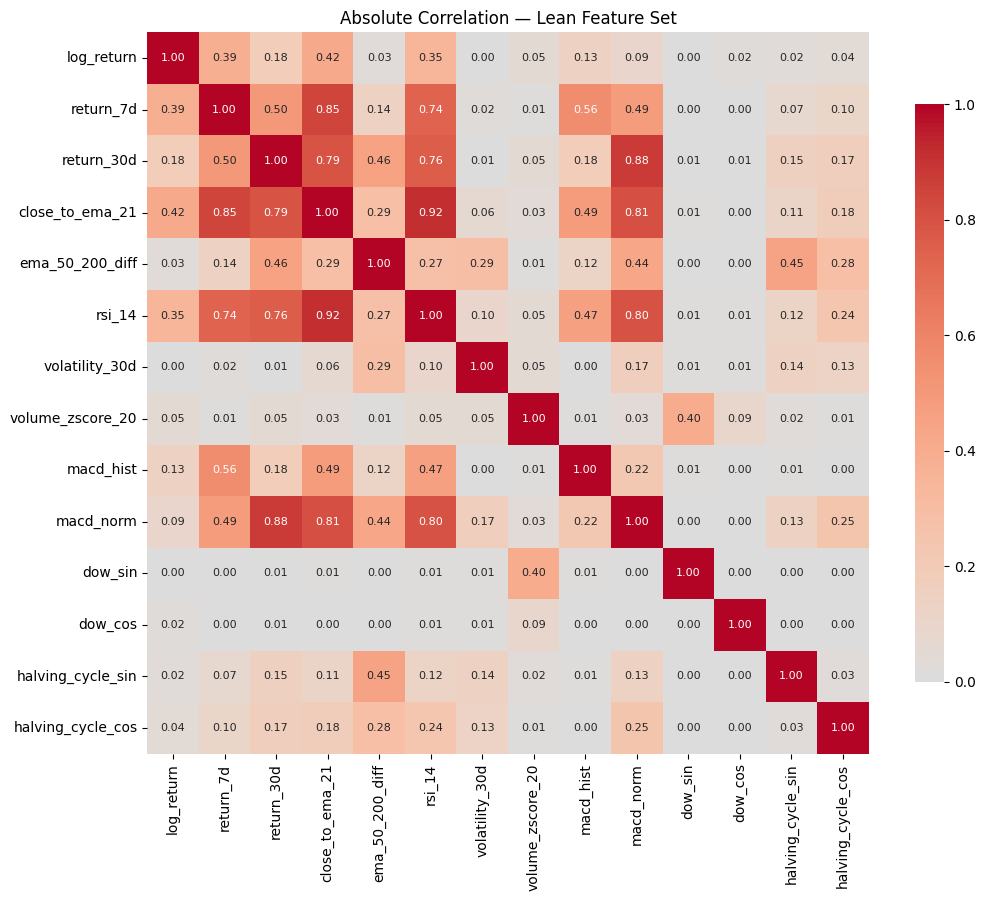

In [16]:
corr = features[feature_cols].corr().abs()

plt.figure(figsize=(11, 9))
sns.heatmap(corr, cmap='coolwarm', center=0, vmin=0, vmax=1,
            square=True, annot=True, fmt='.2f', annot_kws={'size': 8},
            cbar_kws={'shrink': 0.8})
plt.title('Absolute Correlation — Lean Feature Set')
plt.tight_layout()
plt.show()

In [17]:
high_corr_pairs = []
for i in range(len(feature_cols)):
    for j in range(i + 1, len(feature_cols)):
        c = corr.iloc[i, j]
        if c > 0.8:
            high_corr_pairs.append((feature_cols[i], feature_cols[j], c))

if high_corr_pairs:
    print("\nHighly correlated pairs (|corr| > 0.8):")
    for a, b, c in high_corr_pairs:
        print(f"  {a:25s} <-> {b:25s} : {c:.3f}")
else:
    print("\nNo feature pairs above 0.8 correlation. Clean set.")


Highly correlated pairs (|corr| > 0.8):
  return_7d                 <-> close_to_ema_21           : 0.847
  return_30d                <-> macd_norm                 : 0.883
  close_to_ema_21           <-> rsi_14                    : 0.917
  close_to_ema_21           <-> macd_norm                 : 0.809


In [18]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [19]:
n = len(features)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train = features.iloc[:train_end].copy()
val   = features.iloc[train_end:val_end].copy()
test  = features.iloc[val_end:].copy()

print(f"Train: {train.index.min().date()} -> {train.index.max().date()}  ({len(train)} rows)")
print(f"Val:   {val.index.min().date()} -> {val.index.max().date()}  ({len(val)} rows)")
print(f"Test:  {test.index.min().date()} -> {test.index.max().date()}  ({len(test)} rows)\n")

Train: 2017-01-31 -> 2023-05-08  (2296 rows)
Val:   2023-05-09 -> 2024-09-09  (492 rows)
Test:  2024-09-10 -> 2026-01-14  (493 rows)



In [20]:
clusters = {
    'momentum_short':  ['close_to_ema_21', 'rsi_14', 'return_7d'],
    'momentum_medium': ['return_30d', 'macd_norm'],
}

clustered_feats   = [f for feats in clusters.values() for f in feats]
passthrough_feats = [f for f in feature_cols if f not in clustered_feats]

In [21]:
fitted_scalers = {}
fitted_pcas    = {}
n_components_kept = {}

# First pass — fit on train, decide n_components
for cluster_name, feats in clusters.items():
    scaler = StandardScaler()
    train_z = scaler.fit_transform(train[feats])

    pca = PCA(n_components=len(feats))
    pca.fit(train_z)
    var_ratio = pca.explained_variance_ratio_

    n_keep = 1 if var_ratio[0] >= 0.85 else 2

    fitted_scalers[cluster_name] = scaler
    fitted_pcas[cluster_name]    = pca
    n_components_kept[cluster_name] = n_keep

    print(f"Cluster '{cluster_name}' (fit on train):")
    print(f"  Variance per PC: {[f'{v:.1%}' for v in var_ratio]}")
    print(f"  Keeping {n_keep} component(s)")
    print(f"  PC1 loadings:")
    for f, w in zip(feats, pca.components_[0]):
        print(f"    {f:25s}: {w:+.3f}")
    print()

Cluster 'momentum_short' (fit on train):
  Variance per PC: ['89.6%', '8.7%', '1.8%']
  Keeping 1 component(s)
  PC1 loadings:
    close_to_ema_21          : +0.598
    rsi_14                   : +0.577
    return_7d                : +0.557

Cluster 'momentum_medium' (fit on train):
  Variance per PC: ['94.2%', '5.8%']
  Keeping 1 component(s)
  PC1 loadings:
    return_30d               : +0.707
    macd_norm                : +0.707



In [22]:
def transform_split(split_df):
    """Apply train-fitted scalers + PCAs to a split."""
    parts = [split_df[passthrough_feats].copy()]

    for cluster_name, feats in clusters.items():
        scaler = fitted_scalers[cluster_name]
        pca    = fitted_pcas[cluster_name]
        n_keep = n_components_kept[cluster_name]

        z = scaler.transform(split_df[feats])
        comps = pca.transform(z)[:, :n_keep]

        names = [f'{cluster_name}_pc{i+1}' for i in range(n_keep)]
        parts.append(pd.DataFrame(comps, index=split_df.index, columns=names))

    return pd.concat(parts, axis=1)

In [23]:
train_fused = transform_split(train)
val_fused   = transform_split(val)
test_fused  = transform_split(test)

print(f"Fused feature count: {train_fused.shape[1]}")
print(f"Train shape: {train_fused.shape}")
print(f"Val shape:   {val_fused.shape}")
print(f"Test shape:  {test_fused.shape}\n")

Fused feature count: 11
Train shape: (2296, 11)
Val shape:   (492, 11)
Test shape:  (493, 11)



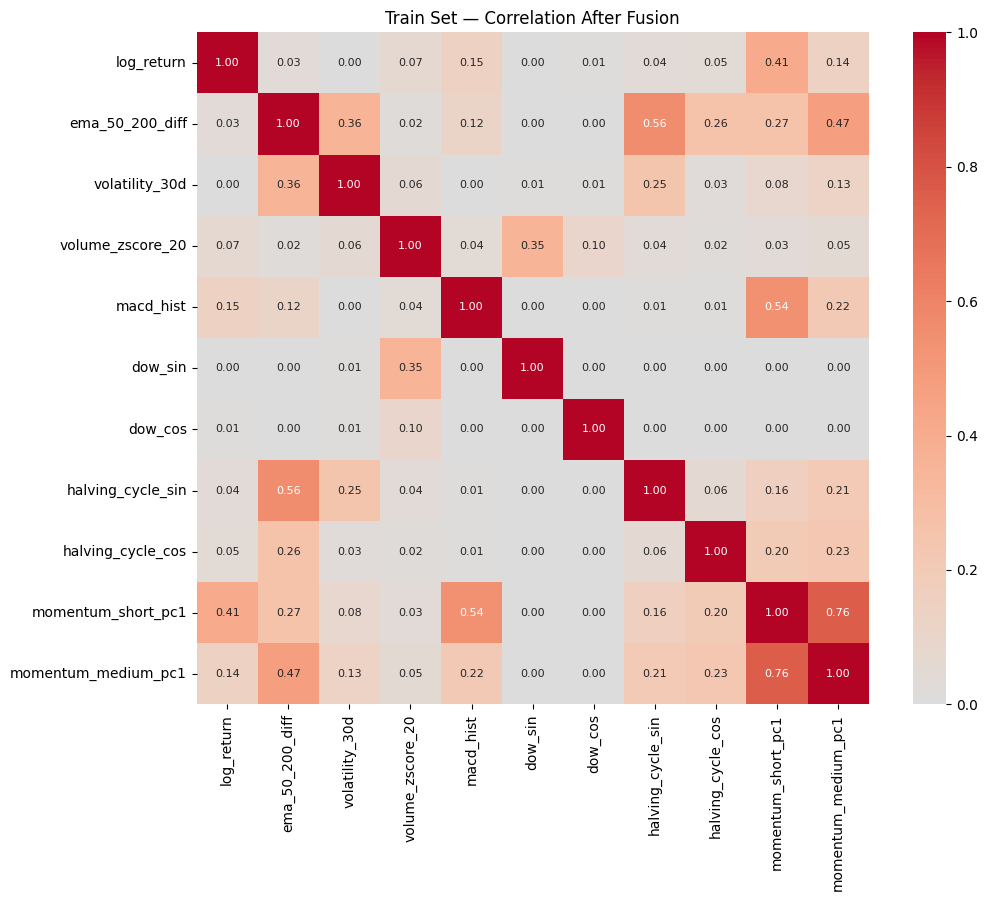

In [24]:
train_corr = train_fused.corr().abs()

plt.figure(figsize=(11, 9))
sns.heatmap(train_corr, cmap='coolwarm', center=0, vmin=0, vmax=1,
            square=True, annot=True, fmt='.2f', annot_kws={'size': 8})
plt.title('Train Set — Correlation After Fusion')
plt.tight_layout()
plt.show()

In [25]:
# Sanity check on val/test — fused features should still be roughly decorrelated
# (won't be exactly zero because PCA was fit on train, not val/test)
print("Max off-diagonal |corr| per split:")
for name, df_split in [('train', train_fused), ('val', val_fused), ('test', test_fused)]:
    c = df_split.corr().abs().values.copy()
    np.fill_diagonal(c, 0)
    print(f"  {name}: {c.max():.3f}")

Max off-diagonal |corr| per split:
  train: 0.763
  val: 0.787
  test: 0.796


In [26]:
def attach_ohlcv(fused_df, original_df):
    return pd.concat([original_df[['Open','High','Low','Close','Volume']], fused_df], axis=1)

train_out = attach_ohlcv(train_fused, train)
val_out   = attach_ohlcv(val_fused,   val)
test_out  = attach_ohlcv(test_fused,  test)

train_out.to_csv('btc_train.csv')
val_out.to_csv('btc_val.csv')
test_out.to_csv('btc_test.csv')

print("\nSaved:")
print(f"  btc_train.csv  ({train_out.shape})")
print(f"  btc_val.csv    ({val_out.shape})")
print(f"  btc_test.csv   ({test_out.shape})")

# Optional: persist the fitted objects so you can reuse them for inference
import pickle
with open('fusion_artifacts.pkl', 'wb') as f:
    pickle.dump({
        'scalers': fitted_scalers,
        'pcas': fitted_pcas,
        'n_components': n_components_kept,
        'clusters': clusters,
        'passthrough_feats': passthrough_feats,
    }, f)
print("  fusion_artifacts.pkl  (scalers + PCAs for inference)")


Saved:
  btc_train.csv  ((2296, 16))
  btc_val.csv    ((492, 16))
  btc_test.csv   ((493, 16))
  fusion_artifacts.pkl  (scalers + PCAs for inference)


#XGBOOST

In [27]:
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
import pickle
import os
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [99]:
SAVE_DIR = '/content/drive/MyDrive/btc_phase3'
os.makedirs(SAVE_DIR, exist_ok=True)

# Set to True to re-run training, False to load from Drive
TRAIN_MODE = False

In [28]:
train = pd.read_csv('btc_train.csv', index_col=0, parse_dates=True)
val   = pd.read_csv('btc_val.csv',   index_col=0, parse_dates=True)
test  = pd.read_csv('btc_test.csv',  index_col=0, parse_dates=True)

print(f"Train: {train.shape}  {train.index.min().date()} -> {train.index.max().date()}")
print(f"Val:   {val.shape}    {val.index.min().date()} -> {val.index.max().date()}")
print(f"Test:  {test.shape}   {test.index.min().date()} -> {test.index.max().date()}")

Train: (2296, 16)  2017-01-31 -> 2023-05-08
Val:   (492, 16)    2023-05-09 -> 2024-09-09
Test:  (493, 16)   2024-09-10 -> 2026-01-14


In [30]:
#Define target and feature columns
TARGET_COL = 'log_return'
OHLCV_COLS = ['Open', 'High', 'Low', 'Close', 'Volume']

feature_cols = [c for c in train.columns if c not in OHLCV_COLS]
print(f"Features ({len(feature_cols)}): {feature_cols}")

def build_xy(df):
    """Build feature matrix X and target y where y[t] = log_return at t+1."""
    X = df[feature_cols].copy()
    y = df[TARGET_COL].shift(-1)
    # Drop the last row (no target available)
    X = X.iloc[:-1]
    y = y.iloc[:-1]
    # Also keep the prices aligned for backtesting later
    prices = df[['Open', 'Close']].iloc[:-1].copy()
    return X, y, prices

X_train, y_train, prices_train = build_xy(train)
X_val,   y_val,   prices_val   = build_xy(val)
X_test,  y_test,  prices_test  = build_xy(test)

print(f"\nX_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape},   y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape},  y_test:  {y_test.shape}")

Features (11): ['log_return', 'ema_50_200_diff', 'volatility_30d', 'volume_zscore_20', 'macd_hist', 'dow_sin', 'dow_cos', 'halving_cycle_sin', 'halving_cycle_cos', 'momentum_short_pc1', 'momentum_medium_pc1']

X_train: (2295, 11), y_train: (2295,)
X_val:   (491, 11),   y_val:   (491,)
X_test:  (492, 11),  y_test:  (492,)


In [100]:
if TRAIN_MODE:
    QUANTILES = [0.1, 0.5, 0.9]
    N_SPLITS = 5

    xgb_params = {
        'objective': 'reg:quantileerror',
        'tree_method': 'hist',
        'learning_rate': 0.03,
        'max_depth': 5,
        'min_child_weight': 5,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'reg_alpha': 0.1,
        'reg_lambda': 1.0,
        'n_estimators': 500,
        'verbosity': 0,
    }

    X_train_reset = X_train.reset_index(drop=True)
    y_train_reset = y_train.reset_index(drop=True)
    train_dates   = X_train.index

    tscv = TimeSeriesSplit(n_splits=N_SPLITS)
    oof_array = np.full((len(X_train_reset), len(QUANTILES)), np.nan)

    print("Training XGBoost with TimeSeriesSplit OOF predictions...\n")
    for fold, (tr_idx, va_idx) in enumerate(tscv.split(X_train_reset), 1):
        X_tr, X_va = X_train_reset.iloc[tr_idx], X_train_reset.iloc[va_idx]
        y_tr, y_va = y_train_reset.iloc[tr_idx], y_train_reset.iloc[va_idx]

        for qi, q in enumerate(QUANTILES):
            params = xgb_params.copy()
            params['quantile_alpha'] = q
            model = xgb.XGBRegressor(**params, early_stopping_rounds=30)
            model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
            preds = model.predict(X_va)
            oof_array[va_idx, qi] = preds

    oof_train = pd.DataFrame(oof_array, index=train_dates, columns=[f'xgb_q{int(q*100)}' for q in QUANTILES])
else:
    print("TRAIN_MODE is False. Skipping XGBoost cross-validation. Artifacts will be loaded from Drive in subsequent steps.")

TRAIN_MODE is False. Skipping XGBoost cross-validation. Artifacts will be loaded from Drive in subsequent steps.


In [101]:
if TRAIN_MODE:
    print("\nTraining final XGBoost models on full training set...")
    final_models = {}
    val_preds  = pd.DataFrame(index=X_val.index, columns=[f'xgb_q{int(q*100)}' for q in QUANTILES])
    test_preds = pd.DataFrame(index=X_test.index, columns=[f'xgb_q{int(q*100)}' for q in QUANTILES])

    for q in QUANTILES:
        params = xgb_params.copy()
        params['quantile_alpha'] = q
        model = xgb.XGBRegressor(**params, early_stopping_rounds=30)
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
        final_models[q] = model
        val_preds[f'xgb_q{int(q*100)}']  = model.predict(X_val)
        test_preds[f'xgb_q{int(q*100)}'] = model.predict(X_test)
else:
    # Load the latest artifacts for evaluation
    import glob
    artifact_files = sorted(glob.glob(os.path.join(SAVE_DIR, 'xgb_artifacts_*.pkl')))
    if artifact_files:
        latest_xgb = artifact_files[-1]
        print(f"Loading latest XGBoost artifacts: {latest_xgb}")
        with open(latest_xgb, 'rb') as f:
            xgb_art = pickle.load(f)
        oof_train = xgb_art['oof_train_preds']
        val_preds = xgb_art['val_preds']
        test_preds = xgb_art['test_preds']
        final_models = xgb_art['models']
    else:
        print("Error: No XGBoost artifacts found in Drive.")

Loading latest XGBoost artifacts: /content/drive/MyDrive/btc_phase3/xgb_artifacts_20260504_165957.pkl


In [44]:
from datetime import datetime

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

xgb_artifacts = {
    'models': final_models,
    'oof_train_preds': oof_train,
    'val_preds': val_preds,
    'test_preds': test_preds,
    'feature_cols': feature_cols,
    'quantiles': QUANTILES,
    'params': xgb_params,
    'timestamp': timestamp
}

# Save with timestamp
artifact_name = f'xgb_artifacts_{timestamp}.pkl'
with open(os.path.join(SAVE_DIR, artifact_name), 'wb') as f:
    pickle.dump(xgb_artifacts, f)

for q, model in final_models.items():
    model_name = f'xgb_q{int(q*100)}_{timestamp}.json'
    model.save_model(os.path.join(SAVE_DIR, model_name))

print(f"\nSaved versioned artifacts to {SAVE_DIR}:")
print(f"  {artifact_name}")
for q in QUANTILES:
    print(f"  xgb_q{int(q*100)}_{timestamp}.json")


Saved versioned artifacts to /content/drive/MyDrive/btc_phase3:
  xgb_artifacts_20260504_165957.pkl
  xgb_q10_20260504_165957.json
  xgb_q50_20260504_165957.json
  xgb_q90_20260504_165957.json


In [45]:
def pinball_loss(y_true, y_pred, q):
    """Pinball loss for a single quantile. Lower is better."""
    diff = y_true - y_pred
    return np.mean(np.maximum(q * diff, (q - 1) * diff))

def evaluate_predictions(y_true, preds_df, label):
    """Compute prediction-quality metrics (not financial metrics)."""
    print(f"\n--- {label} prediction metrics ---")
    # Use .values to avoid index alignment issues during calculation
    q50 = preds_df['xgb_q50'].values
    q10 = preds_df['xgb_q10'].values
    q90 = preds_df['xgb_q90'].values
    y = y_true.values

    # Point estimate metrics (using Q50 as point forecast)
    mse = np.mean((y - q50) ** 2)
    mae = np.mean(np.abs(y - q50))
    dir_acc = np.mean(np.sign(y) == np.sign(q50))

    # Quantile-specific
    pl10 = pinball_loss(y, q10, 0.1)
    pl50 = pinball_loss(y, q50, 0.5)
    pl90 = pinball_loss(y, q90, 0.9)

    # Calibration: % of true values inside [Q10, Q90]. Should be ~80%.
    inside = np.mean((y >= q10) & (y <= q90))

    # Average predicted spread (uncertainty)
    avg_spread = np.mean(q90 - q10)

    print(f"  MSE:                  {mse:.6f}")
    print(f"  MAE:                  {mae:.6f}")
    print(f"  Directional accuracy: {dir_acc:.4f}")
    print(f"  Pinball loss Q10:     {pl10:.6f}")
    print(f"  Pinball loss Q50:     {pl50:.6f}")
    print(f"  Pinball loss Q90:     {pl90:.6f}")
    print(f"  80% interval coverage: {inside:.4f}  (target: 0.80)")
    print(f"  Avg predicted spread: {avg_spread:.6f}")

    return {
        'mse': mse, 'mae': mae, 'dir_acc': dir_acc,
        'pinball_10': pl10, 'pinball_50': pl50, 'pinball_90': pl90,
        'coverage_80': inside, 'avg_spread': avg_spread,
    }

# Fix: Positional alignment to handle potential duplicate indices in y_train
mask = oof_train.notna().all(axis=1)
oof_clean = oof_train[mask]
y_train_clean = y_train[mask.values] # Use .values to ensure positional masking

metrics_train = evaluate_predictions(y_train_clean, oof_clean, 'OOF Train')
metrics_val   = evaluate_predictions(y_val,        val_preds,  'Val')
metrics_test  = evaluate_predictions(y_test,       test_preds, 'Test')


--- OOF Train prediction metrics ---
  MSE:                  0.001469
  MAE:                  0.025563
  Directional accuracy: 0.5147
  Pinball loss Q10:     0.007054
  Pinball loss Q50:     0.012782
  Pinball loss Q90:     0.006728
  80% interval coverage: 0.8461  (target: 0.80)
  Avg predicted spread: 0.097693

--- Val prediction metrics ---
  MSE:                  0.000633
  MAE:                  0.017330
  Directional accuracy: 0.5071
  Pinball loss Q10:     0.004562
  Pinball loss Q50:     0.008665
  Pinball loss Q90:     0.004748
  80% interval coverage: 0.8717  (target: 0.80)
  Avg predicted spread: 0.070629

--- Test prediction metrics ---
  MSE:                  0.000507
  MAE:                  0.016240
  Directional accuracy: 0.5081
  Pinball loss Q10:     0.004651
  Pinball loss Q50:     0.008120
  Pinball loss Q90:     0.004445
  80% interval coverage: 0.8963  (target: 0.80)
  Avg predicted spread: 0.077460


In [55]:
def backtest(predictions_df, prices_df, y_true, strategy='naive_directional',
             fee_pct=0.001, slippage_pct=0.0005, max_position=1.0,
             confidence_threshold=None):
    """
    Run a backtest. Returns (equity_curve, daily_returns, metrics_dict).

    predictions_df: DataFrame with columns ['xgb_q10', 'xgb_q50', 'xgb_q90']
    prices_df:      DataFrame with columns ['Open', 'Close'], aligned with predictions_df
    y_true:         Series of actual log returns (next-day), aligned with predictions_df
    strategy:       'naive_directional', 'confidence_gated', 'magnitude_sized', 'risk_adjusted'
    fee_pct:        Per-trade fee as decimal (0.001 = 0.1%)
    slippage_pct:   Per-trade slippage as decimal
    max_position:   Position size cap (1.0 = 100% of capital, no leverage)

    Convention: prediction at row t is for return from t to t+1. We "trade" at the close
    of day t based on the prediction, hold for one day, and realize y_true[t] as our return.
    """
    q10 = predictions_df['xgb_q10'].values
    q50 = predictions_df['xgb_q50'].values
    q90 = predictions_df['xgb_q90'].values
    actual_returns = y_true.values

    # Determine target position for each day based on strategy
    positions = np.zeros(len(q50))

    if strategy == 'naive_directional':
        positions = np.sign(q50) * max_position

    elif strategy == 'confidence_gated':
      spread = np.maximum(q90 - q10, 1e-9)
      ratio = np.abs(q50) / spread
      confident = ratio > confidence_threshold
      positions = np.where(confident, np.sign(q50) * max_position, 0)

    elif strategy == 'magnitude_sized':
        # Position proportional to |Q50|, scaled so typical prediction uses ~50% capital
        scale = max_position / (np.abs(q50).mean() * 2 + 1e-9)
        positions = np.clip(q50 * scale, -max_position, max_position)

    elif strategy == 'risk_adjusted':
        # Kelly-flavored: position = Q50 / (Q90 - Q10), normalized
        spread = np.maximum(q90 - q10, 1e-6)
        raw = q50 / spread
        scale = max_position / (np.abs(raw).mean() * 2 + 1e-9)
        positions = np.clip(raw * scale, -max_position, max_position)

    elif strategy == 'buy_and_hold':
        positions = np.ones(len(q50)) * max_position

    else:
        raise ValueError(f"Unknown strategy: {strategy}")

    # Compute daily returns: position[t] * actual_return[t]
    # Then subtract trading costs whenever position changes
    daily_returns = np.zeros(len(positions))
    prev_position = 0.0
    for t in range(len(positions)):
        # Trading cost on position change
        position_change = abs(positions[t] - prev_position)
        cost = position_change * (fee_pct + slippage_pct)
        # Return from holding
        gross = positions[t] * actual_returns[t]
        daily_returns[t] = gross - cost
        prev_position = positions[t]

    # Equity curve (start at 1.0)
    equity = np.cumprod(1 + daily_returns)
    equity_series = pd.Series(equity, index=predictions_df.index)

    # Metrics
    n_days = len(daily_returns)
    total_return = equity[-1] - 1
    ann_return = (equity[-1]) ** (365 / n_days) - 1
    ann_vol = daily_returns.std() * np.sqrt(365)
    sharpe = ann_return / ann_vol if ann_vol > 0 else 0
    rolling_max = np.maximum.accumulate(equity)
    drawdown = (equity - rolling_max) / rolling_max
    max_dd = drawdown.min()
    calmar = ann_return / abs(max_dd) if max_dd < 0 else np.nan
    win_rate = np.mean(daily_returns > 0)
    n_trades = (np.diff(positions, prepend=0) != 0).sum()

    metrics = {
        'strategy': strategy,
        'cumulative_return': total_return,
        'annualized_return': ann_return,
        'annualized_vol': ann_vol,
        'sharpe': sharpe,
        'max_drawdown': max_dd,
        'calmar': calmar,
        'win_rate': win_rate,
        'n_trades': int(n_trades),
        'n_days': n_days,
    }

    return equity_series, pd.Series(daily_returns, index=predictions_df.index), metrics

In [56]:
# Compute confidence threshold on validation set (no leakage)
val_spread = np.maximum(val_preds['xgb_q90'].values - val_preds['xgb_q10'].values, 1e-9)
val_ratio = np.abs(val_preds['xgb_q50'].values) / val_spread
CONFIDENCE_THRESHOLD = np.percentile(val_ratio, 70)
print(f"Confidence threshold (from val, top 30%): {CONFIDENCE_THRESHOLD:.4f}")

Confidence threshold (from val, top 30%): 0.0327


In [62]:
strategies = ['buy_and_hold', 'naive_directional', 'confidence_gated',
              'magnitude_sized', 'risk_adjusted']

results = {}
print(f"\n{'='*70}")
print(f"XGBoost-only backtest results on TEST set")
print(f"(fees=0.1%, slippage=0.05%, capital cap=100%)")
print(f"{'='*70}")

for strat in strategies:
    eq, ret, met = backtest(test_preds, prices_test, y_test,
                            strategy=strat,
                            confidence_threshold=CONFIDENCE_THRESHOLD)
    results[strat] = {'equity': eq, 'returns': ret, 'metrics': met}

# Pretty-print metrics table
metrics_table = pd.DataFrame([results[s]['metrics'] for s in strategies])
metrics_table = metrics_table.set_index('strategy')
metrics_table_display = metrics_table.copy()
for col in ['cumulative_return', 'annualized_return', 'annualized_vol',
            'max_drawdown', 'win_rate']:
    metrics_table_display[col] = metrics_table_display[col].apply(lambda x: f'{x:.2%}')
for col in ['sharpe', 'calmar']:
    metrics_table_display[col] = metrics_table_display[col].apply(lambda x: f'{x:.3f}')

print()
print(metrics_table_display.to_string())


XGBoost-only backtest results on TEST set
(fees=0.1%, slippage=0.05%, capital cap=100%)

                  cumulative_return annualized_return annualized_vol sharpe max_drawdown calmar win_rate  n_trades  n_days
strategy                                                                                                                  
buy_and_hold                 48.38%            34.01%         42.90%  0.793      -33.08%  1.028   51.02%         1     492
naive_directional             8.61%             6.32%         43.00%  0.147      -41.44%  0.153   50.20%        69     492
confidence_gated             45.17%            31.86%         28.56%  1.115      -26.28%  1.212   27.64%       134     492
magnitude_sized              14.41%            10.50%         23.69%  0.443      -19.44%  0.540   46.95%       489     492
risk_adjusted                12.93%             9.44%         22.37%  0.422      -20.59%  0.458   46.95%       484     492


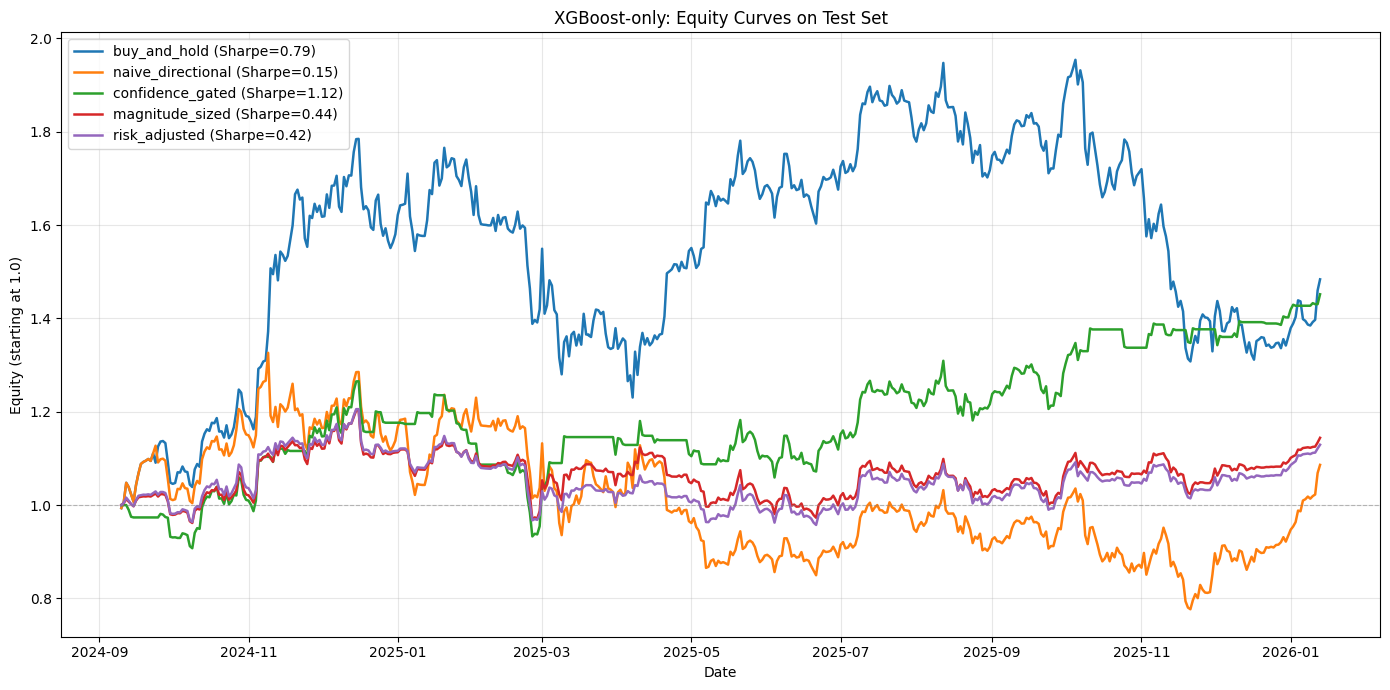

In [59]:
plt.figure(figsize=(14, 7))
for strat in strategies:
    plt.plot(results[strat]['equity'].index, results[strat]['equity'].values,
             label=f"{strat} (Sharpe={results[strat]['metrics']['sharpe']:.2f})",
             linewidth=1.8)

plt.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
plt.title('XGBoost-only: Equity Curves on Test Set')
plt.xlabel('Date')
plt.ylabel('Equity (starting at 1.0)')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'xgb_equity_curves.png'), dpi=120)
plt.show()


Saved evaluation report (version 20260504_165957):
  /content/drive/MyDrive/btc_phase3/xgb_eval_report_20260504_165957.pkl
  /content/drive/MyDrive/btc_phase3/xgb_backtest_metrics_20260504_165957.csv
  /content/drive/MyDrive/btc_phase3/xgb_equity_curves_20260504_165957.png


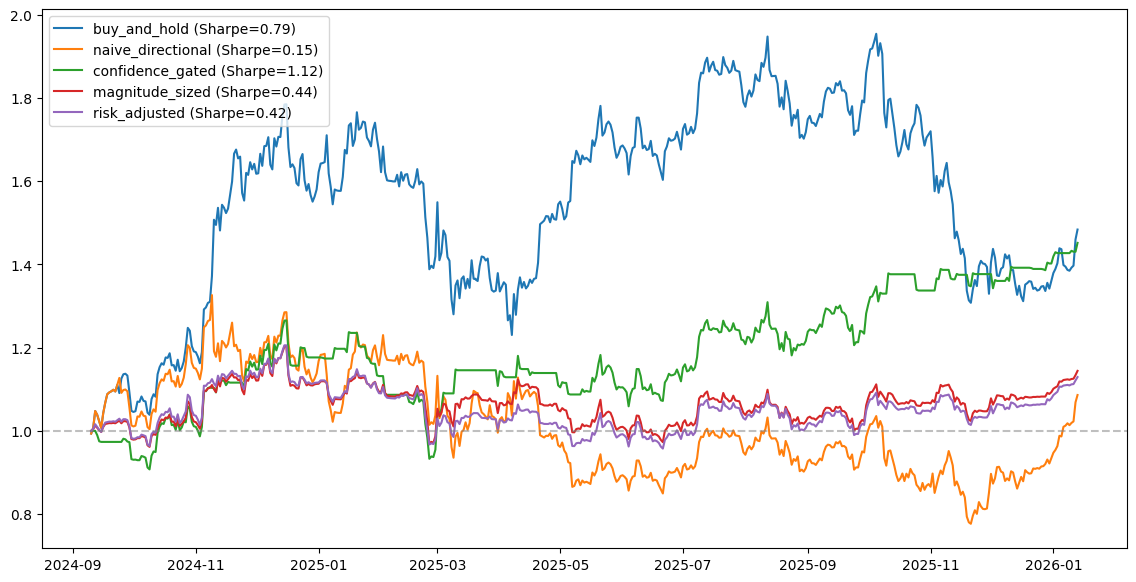

In [60]:
report = {
    'prediction_metrics': {
        'oof_train': metrics_train,
        'val': metrics_val,
        'test': metrics_test,
    },
    'backtest_metrics': {s: results[s]['metrics'] for s in strategies},
    'equity_curves': {s: results[s]['equity'] for s in strategies},
}

report_name = f'xgb_eval_report_{timestamp}.pkl'
csv_name = f'xgb_backtest_metrics_{timestamp}.csv'
img_name = f'xgb_equity_curves_{timestamp}.png'

with open(os.path.join(SAVE_DIR, report_name), 'wb') as f:
    pickle.dump(report, f)

metrics_table.to_csv(os.path.join(SAVE_DIR, csv_name))

# Also save the plot if it was generated in the previous cell
plt.figure(figsize=(14, 7))
for strat in strategies:
    plt.plot(results[strat]['equity'].index, results[strat]['equity'].values,
             label=f"{strat} (Sharpe={results[strat]['metrics']['sharpe']:.2f})")
plt.axhline(1.0, color='gray', linestyle='--', alpha=0.5)
plt.legend(loc='best')
plt.savefig(os.path.join(SAVE_DIR, img_name), dpi=120)

print(f"\nSaved evaluation report (version {timestamp}):")
print(f"  {SAVE_DIR}/{report_name}")
print(f"  {SAVE_DIR}/{csv_name}")
print(f"  {SAVE_DIR}/{img_name}")

#TEMPORAL FUSION TRANSFORMER

In [74]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

# Consistent imports using the lightning.pytorch namespace
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss
from pytorch_forecasting.data import GroupNormalizer

In [75]:
#merge xgb predictions as features

print(f"GPU available: {torch.cuda.is_available()}")
print(f"Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
train = pd.read_csv('btc_train.csv', index_col=0, parse_dates=True)
val   = pd.read_csv('btc_val.csv',   index_col=0, parse_dates=True)
test  = pd.read_csv('btc_test.csv',  index_col=0, parse_dates=True)

with open(os.path.join(SAVE_DIR, 'xgb_artifacts.pkl'), 'rb') as f:
    xgb_art = pickle.load(f)

oof_train = xgb_art['oof_train_preds']   # OOF preds for training (leak-free)
val_preds = xgb_art['val_preds']
test_preds = xgb_art['test_preds']

# Merge xgb predictions into each split. NaN rows in OOF train will be dropped.
train = train.join(oof_train, how='left')
val   = val.join(val_preds, how='left')
test  = test.join(test_preds, how='left')

# Drop rows missing xgb predictions (early training rows from first CV fold)
train = train.dropna(subset=['xgb_q10', 'xgb_q50', 'xgb_q90'])
val   = val.dropna(subset=['xgb_q10', 'xgb_q50', 'xgb_q90'])
test  = test.dropna(subset=['xgb_q10', 'xgb_q50', 'xgb_q90'])

print(f"Train: {train.shape}  {train.index.min().date()} -> {train.index.max().date()}")
print(f"Val:   {val.shape}    {val.index.min().date()} -> {val.index.max().date()}")
print(f"Test:  {test.shape}   {test.index.min().date()} -> {test.index.max().date()}")

GPU available: True
Device: Tesla T4
Train: (1922, 19)  2018-02-19 -> 2023-05-07
Val:   (495, 19)    2023-05-09 -> 2024-09-08
Test:  (494, 19)   2024-09-10 -> 2026-01-13


In [76]:
OHLCV_COLS = ['Open', 'High', 'Low', 'Close', 'Volume']
TARGET_COL = 'log_return_next'

for df in (train, val, test):
    df[TARGET_COL] = df['log_return'].shift(-1)

train = train.iloc[:-1].copy()
val   = val.iloc[:-1].copy()
test  = test.iloc[:-1].copy()

# Concatenate, add group + time_idx
full = pd.concat([train, val, test], axis=0)
full['group'] = 'BTC'
full['time_idx'] = np.arange(len(full))

# Mark which split each row belongs to (we'll use this for cutoffs)
n_train = len(train)
n_val   = len(val)
n_test  = len(test)
TRAIN_END = n_train - 1                  # last train idx
VAL_END   = n_train + n_val - 1          # last val idx

print(f"Total rows: {len(full)}")
print(f"Train idx: 0 -> {TRAIN_END}")
print(f"Val idx:   {TRAIN_END+1} -> {VAL_END}")
print(f"Test idx:  {VAL_END+1} -> {len(full)-1}")

exclude = set(OHLCV_COLS + [TARGET_COL, 'group', 'time_idx', 'log_return'])
feature_cols = [c for c in full.columns if c not in exclude]
print(f"\nFeature count: {len(feature_cols)}")
print(f"Features: {feature_cols}")

Total rows: 2908
Train idx: 0 -> 1920
Val idx:   1921 -> 2414
Test idx:  2415 -> 2907

Feature count: 13
Features: ['ema_50_200_diff', 'volatility_30d', 'volume_zscore_20', 'macd_hist', 'dow_sin', 'dow_cos', 'halving_cycle_sin', 'halving_cycle_cos', 'momentum_short_pc1', 'momentum_medium_pc1', 'xgb_q10', 'xgb_q50', 'xgb_q90']


In [77]:
ENCODER_LEN = 60
PREDICTION_LEN = 1

KNOWN_FUTURE_FEATS = ['dow_sin', 'dow_cos', 'halving_cycle_sin', 'halving_cycle_cos']
UNKNOWN_FEATS = [c for c in feature_cols if c not in KNOWN_FUTURE_FEATS]

# FIX: Ensure the dataframe index is unique as required by TimeSeriesDataSet
full_unique = full.reset_index(drop=True)

training_dataset = TimeSeriesDataSet(
    full_unique[full_unique.time_idx <= TRAIN_END],
    time_idx='time_idx',
    target=TARGET_COL,
    group_ids=['group'],
    max_encoder_length=ENCODER_LEN,
    min_encoder_length=ENCODER_LEN,
    max_prediction_length=PREDICTION_LEN,
    min_prediction_length=PREDICTION_LEN,
    static_categoricals=['group'],
    time_varying_known_reals=KNOWN_FUTURE_FEATS,
    time_varying_unknown_reals=UNKNOWN_FEATS + [TARGET_COL],
    target_normalizer=GroupNormalizer(groups=['group'], transformation=None),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=False,
    allow_missing_timesteps=False,
)

validation_dataset = TimeSeriesDataSet.from_dataset(
    training_dataset,
    full_unique[full_unique.time_idx <= VAL_END],
    predict=False,
    stop_randomization=True,
    min_prediction_idx=TRAIN_END + 1,
)

test_dataset = TimeSeriesDataSet.from_dataset(
    training_dataset,
    full_unique,
    predict=False,
    stop_randomization=True,
    min_prediction_idx=VAL_END + 1,
)

print(f"\nTraining samples: {len(training_dataset)}")
print(f"Validation samples: {len(validation_dataset)}")
print(f"Test samples: {len(test_dataset)}")


Training samples: 1861
Validation samples: 494
Test samples: 493


In [78]:
BATCH_SIZE = 64

train_loader = training_dataset.to_dataloader(train=True,  batch_size=BATCH_SIZE,
                                              num_workers=2, shuffle=True)
val_loader   = validation_dataset.to_dataloader(train=False, batch_size=BATCH_SIZE,
                                                num_workers=2)
test_loader  = test_dataset.to_dataloader(train=False, batch_size=BATCH_SIZE,
                                          num_workers=2)

In [82]:
print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 29
Val batches:   8
Test batches:  8


In [79]:
QUANTILES = [0.1, 0.5, 0.9]

tft = TemporalFusionTransformer.from_dataset(
    training_dataset,
    learning_rate=1e-3,
    hidden_size=32,
    attention_head_size=4,
    dropout=0.2,
    hidden_continuous_size=16,
    loss=QuantileLoss(quantiles=QUANTILES),
    log_interval=10,
    reduce_on_plateau_patience=4,
    optimizer='adam',
)
print(f"TFT parameters: {sum(p.numel() for p in tft.parameters()):,}")

TFT parameters: 98,695


In [102]:
if TRAIN_MODE:
    checkpoint = ModelCheckpoint(dirpath=SAVE_DIR, filename='tft-{epoch:02d}-{val_loss:.4f}', monitor='val_loss', mode='min', save_top_k=1)
    early_stop = EarlyStopping(monitor='val_loss', patience=10, mode='min', verbose=True)

    trainer = pl.Trainer(max_epochs=50, accelerator='auto', devices=1, gradient_clip_val=0.1, callbacks=[early_stop, checkpoint])
    trainer.fit(tft, train_dataloaders=train_loader, val_dataloaders=val_loader)

    best_path = checkpoint.best_model_path
    tft = TemporalFusionTransformer.load_from_checkpoint(best_path)
else:
    import glob
    ckpt_files = sorted(glob.glob(os.path.join(SAVE_DIR, 'tft*.ckpt')))
    if ckpt_files:
        best_path = ckpt_files[-1]
        print(f"Loading latest TFT checkpoint: {best_path}")
        tft = TemporalFusionTransformer.load_from_checkpoint(best_path)
    else:
        print("Error: No TFT checkpoints found in Drive.")

Loading latest TFT checkpoint: /content/drive/MyDrive/btc_phase3/tft_best_valloss_0.0120.ckpt


In [86]:
def predict_quantiles(model, dataloader):
    raw = model.predict(dataloader, mode='raw', return_index=True)
    preds = raw.output.prediction.cpu().numpy()[:, 0, :]   # (N, 3)
    target_time_idx = raw.index['time_idx'].values
    df = pd.DataFrame(
        preds,
        columns=['tft_q10', 'tft_q50', 'tft_q90'],
        index=target_time_idx,
    )
    df.index.name = 'time_idx'
    return df.sort_index()

val_tft  = predict_quantiles(tft, val_loader)
test_tft = predict_quantiles(tft, test_loader)

idx_to_date = pd.Series(full.index.values, index=full['time_idx'].values)

val_tft.index  = pd.DatetimeIndex(idx_to_date.loc[val_tft.index].values, name='date')
test_tft.index = pd.DatetimeIndex(idx_to_date.loc[test_tft.index].values, name='date')

print(f"Val predictions:  {val_tft.shape}  ({val_tft.index.min().date()} -> {val_tft.index.max().date()})")
print(f"Test predictions: {test_tft.shape} ({test_tft.index.min().date()} -> {test_tft.index.max().date()})")
val_tft.head()

Val predictions:  (494, 3)  (2023-05-09 -> 2024-09-07)
Test predictions: (493, 3) (2024-09-10 -> 2026-01-12)


,tft_q10,tft_q50,tft_q90
date,,,
2023-05-09,-0.027025,-0.000037,0.029545
2023-05-10,-0.036708,-0.003641,0.028210
2023-05-11,-0.033491,-0.000811,0.027164
2023-05-12,-0.022081,-0.001159,0.017602
2023-05-13,-0.029813,-0.003336,0.021689


In [115]:
# Defensive alignment — correctly ordering the mapping to avoid circular references

# 1. Start with the raw model outputs (using the correct dataframe names from predict_quantiles)
val_tft_named = val_tft.rename(columns={'tft_q10': 'xgb_q10', 'tft_q50': 'xgb_q50', 'tft_q90': 'xgb_q90'})
test_tft_named = test_tft.rename(columns={'tft_q10': 'xgb_q10', 'tft_q50': 'xgb_q50', 'tft_q90': 'xgb_q90'})

# 2. Join with the ground truth from the original splits
val_eval = val_tft_named.join(val[[TARGET_COL]].rename(columns={TARGET_COL: 'y_true'}),
                              how='inner').dropna()
test_eval = test_tft_named.join(test[[TARGET_COL]].rename(columns={TARGET_COL: 'y_true'}),
                                how='inner').dropna()

# 3. Extract aligned targets and prices using the synchronized index
y_val_aligned  = val_eval['y_true']
y_test_aligned = test_eval['y_true']

prices_val_aligned  = val.loc[val_eval.index,  ['Open', 'Close']]
prices_test_aligned = test.loc[test_eval.index, ['Open', 'Close']]

print(f"Val aligned:  {len(val_eval)} rows")
print(f"Test aligned: {len(test_eval)} rows")

# Verify shapes match exactly for evaluation
assert len(y_val_aligned) == len(val_eval)
assert len(y_test_aligned) == len(test_eval)

Val aligned:  518 rows
Test aligned: 505 rows


In [117]:
print("\n=== TFT prediction metrics ===")

# Ensure exact alignment before passing to the evaluation function
val_eval_final = val_tft_named.join(y_val_aligned.to_frame(), how='inner').dropna()
test_eval_final = test_tft_named.join(y_test_aligned.to_frame(), how='inner').dropna()

metrics_val_tft  = evaluate_predictions(val_eval_final['y_true'],  val_eval_final[val_tft_named.columns],  'TFT Val')
metrics_test_tft = evaluate_predictions(test_eval_final['y_true'], test_eval_final[test_tft_named.columns], 'TFT Test')


=== TFT prediction metrics ===

--- TFT Val prediction metrics ---
  MSE:                  0.000515
  MAE:                  0.014901
  Directional accuracy: 0.4821
  Pinball loss Q10:     0.004404
  Pinball loss Q50:     0.007451
  Pinball loss Q90:     0.004332
  80% interval coverage: 0.8925  (target: 0.80)
  Avg predicted spread: 0.070496

--- TFT Test prediction metrics ---
  MSE:                  0.000481
  MAE:                  0.015631
  Directional accuracy: 0.4467
  Pinball loss Q10:     0.003949
  Pinball loss Q50:     0.007816
  Pinball loss Q90:     0.004672
  80% interval coverage: 0.9150  (target: 0.80)
  Avg predicted spread: 0.073699


In [118]:
# Recompute confidence threshold from TFT val predictions
val_spread_tft = np.maximum(val_tft['tft_q90'].values - val_tft['tft_q10'].values, 1e-9)
val_ratio_tft  = np.abs(val_tft['tft_q50'].values) / val_spread_tft
TFT_CONFIDENCE_THRESHOLD = np.percentile(val_ratio_tft, 70)
print(f"TFT confidence threshold (from val): {TFT_CONFIDENCE_THRESHOLD:.4f}")

strategies = ['buy_and_hold', 'naive_directional', 'confidence_gated',
              'magnitude_sized', 'risk_adjusted']

tft_results = {}
print(f"\n{'='*70}")
print(f"TFT-only backtest results on TEST set")
print(f"{'='*70}")

for strat in strategies:
    eq, ret, met = backtest(test_tft_named, prices_test_aligned, y_test_aligned,
                            strategy=strat,
                            confidence_threshold=TFT_CONFIDENCE_THRESHOLD)
    tft_results[strat] = {'equity': eq, 'returns': ret, 'metrics': met}

tft_metrics_table = pd.DataFrame([tft_results[s]['metrics'] for s in strategies]).set_index('strategy')
disp = tft_metrics_table.copy()
for col in ['cumulative_return', 'annualized_return', 'annualized_vol', 'max_drawdown', 'win_rate']:
    disp[col] = disp[col].apply(lambda x: f'{x:.2%}')
for col in ['sharpe', 'calmar']:
    disp[col] = disp[col].apply(lambda x: f'{x:.3f}')
print()
print(disp.to_string())

TFT confidence threshold (from val): 0.0345

TFT-only backtest results on TEST set

                  cumulative_return annualized_return annualized_vol sharpe max_drawdown calmar win_rate  n_trades  n_days
strategy                                                                                                                  
buy_and_hold                 19.20%            13.89%         42.88%  0.324      -39.61%  0.351   49.29%         1     493
naive_directional            19.30%            13.96%         42.99%  0.325      -44.60%  0.313   50.71%        46     493
confidence_gated              2.53%             1.87%         34.51%  0.054      -35.73%  0.052   31.85%       128     493
magnitude_sized              15.91%            11.55%         27.25%  0.424      -22.83%  0.506   47.26%       484     493
risk_adjusted                16.24%            11.79%         26.05%  0.453      -23.01%  0.512   47.06%       485     493


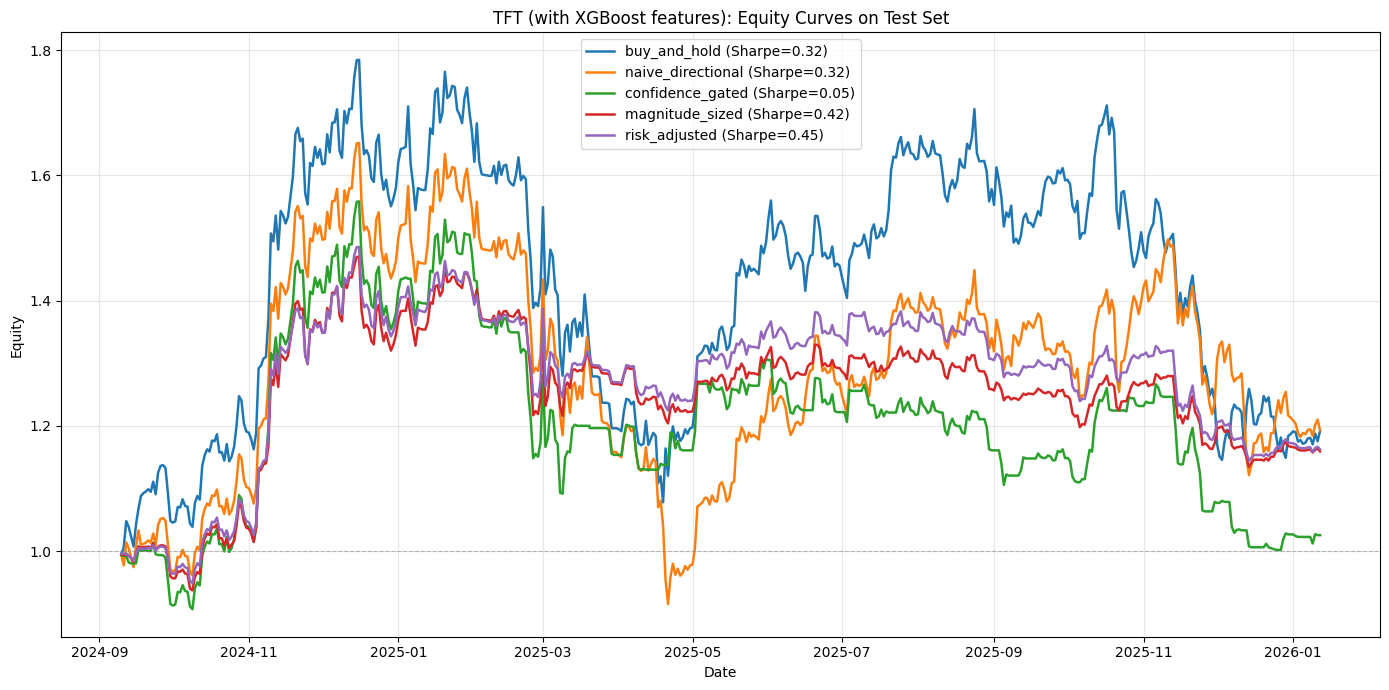

In [119]:
plt.figure(figsize=(14, 7))
for strat in strategies:
    plt.plot(tft_results[strat]['equity'].index, tft_results[strat]['equity'].values,
             label=f"{strat} (Sharpe={tft_results[strat]['metrics']['sharpe']:.2f})",
             linewidth=1.8)
plt.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
plt.title('TFT (with XGBoost features): Equity Curves on Test Set')
plt.xlabel('Date')
plt.ylabel('Equity')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'tft_equity_curves.png'), dpi=120)
plt.show()

In [108]:
tft_report = {
    'prediction_metrics': {'val': metrics_val_tft, 'test': metrics_test_tft},
    'val_predictions': val_tft,
    'test_predictions': test_tft,
    'backtest_metrics': {s: tft_results[s]['metrics'] for s in strategies},
    'equity_curves': {s: tft_results[s]['equity'] for s in strategies},
    'confidence_threshold': TFT_CONFIDENCE_THRESHOLD,
    'best_checkpoint': best_path,
}
with open(os.path.join(SAVE_DIR, 'tft_eval_report.pkl'), 'wb') as f:
    pickle.dump(tft_report, f)
tft_metrics_table.to_csv(os.path.join(SAVE_DIR, 'tft_backtest_metrics.csv'))

print(f"\nSaved:")
print(f"  {SAVE_DIR}/tft_best.ckpt")
print(f"  {SAVE_DIR}/tft_eval_report.pkl")
print(f"  {SAVE_DIR}/tft_backtest_metrics.csv")
print(f"  {SAVE_DIR}/tft_equity_curves.png")


Saved:
  /content/drive/MyDrive/btc_phase3/tft_best.ckpt
  /content/drive/MyDrive/btc_phase3/tft_eval_report.pkl
  /content/drive/MyDrive/btc_phase3/tft_backtest_metrics.csv
  /content/drive/MyDrive/btc_phase3/tft_equity_curves.png
